<a href="https://colab.research.google.com/github/walalakhider/tp5-facenet-face-recognition/blob/main/TP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installation des dépendances**

In [2]:
!pip install -q tensorflow keras mtcnn deepface
!pip install -q opencv-python-headless numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00


**Imports**

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from mtcnn import MTCNN
from deepface import DeepFace

26-03-14 22:36:39 - Directory /root/.deepface has been created
26-03-14 22:36:39 - Directory /root/.deepface/weights has been created


# Classe FaceRecognitionDL

In [4]:
class FaceRecognitionDL:
    """
    Reconnaissance faciale par Deep Learning.
    Pipeline : MTCNN (detection) -> FaceNet (embedding) -> distance cosinus/euclidienne
    """

    def __init__(self, model_name="Facenet"):
        """
        Initialise :
          - detecteur MTCNN
          - modele FaceNet via DeepFace
          - base d'embeddings (liste de dicts {label, embedding})
          - taille cible du visage : 160x160
        """
        print("Chargement du detecteur MTCNN...")
        self.detector  = MTCNN()
        self.model_name = model_name   # 'Facenet' ou 'ArcFace'
        self.database  = []            # [{label, embedding}, ...]
        self.face_size = (160, 160)
        print(f"Modele selectionne : {self.model_name}")
        print("Initialisation OK.")

    # ──────────────────────────────────────────
    # 1. DETECTION DU VISAGE (MTCNN)
    # ──────────────────────────────────────────
    def detect_face(self, image):
        """
        Entree  : image RGB (numpy array)
        Sortie  : visage crop 160x160 (RGB) ou None
        Etapes  : detection MTCNN -> plus grand visage -> resize 160x160
        """
        results = self.detector.detect_faces(image)
        if not results:
            return None, None

        # Plus grand visage (aire maximale)
        results = sorted(results, key=lambda r: r['box'][2]*r['box'][3], reverse=True)
        x, y, w, h = results[0]['box']

        # Clamp pour eviter les coordonnees negatives
        x, y = max(0, x), max(0, y)
        face_roi = image[y:y+h, x:x+w]
        if face_roi.size == 0:
            return None, None

        face_resized = cv2.resize(face_roi, self.face_size)
        bbox = (x, y, w, h)
        return face_resized, bbox

    # ──────────────────────────────────────────
    # 2. EXTRACTION D'EMBEDDING
    # ──────────────────────────────────────────
    def extract_embedding(self, face):
        """
        Entree  : image visage RGB 160x160
        Sortie  : vecteur embedding normalise (128 ou 512 dims)
        Etapes  : normalisation -> passage dans CNN -> normalisation L2
        """
        # Normalisation pixel [0,255] -> [-1,1]
        face_norm = (face.astype(np.float32) - 127.5) / 128.0
        face_norm = np.expand_dims(face_norm, axis=0)   # (1, 160, 160, 3)

        # Extraction via DeepFace (represente le modele)
        embedding = DeepFace.represent(
            img_path   = face,
            model_name = self.model_name,
            enforce_detection = False,
            detector_backend  = 'skip'
        )[0]['embedding']

        embedding = np.array(embedding)

        # Normalisation L2
        norm = np.linalg.norm(embedding)
        if norm > 0:
            embedding = embedding / norm

        return embedding

    # ──────────────────────────────────────────
    # 3. CONSTRUCTION DE LA BASE
    # ──────────────────────────────────────────
    def build_database(self, dataset_path):
        """
        Parcourt un dossier structure par personne :
            dataset/
                person1/   img1.jpg ...
                person2/   img1.jpg ...

        Pour chaque image :
          - detecte le visage (MTCNN)
          - extrait l'embedding (FaceNet)
          - stocke {label, embedding} dans self.database
        """
        self.database = []
        dataset_path  = Path(dataset_path)

        print(f"\nConstruction de la base : {dataset_path}")
        print("-" * 50)

        for person_dir in sorted(dataset_path.iterdir()):
            if not person_dir.is_dir():
                continue
            person_name = person_dir.name
            count = 0

            for img_path in sorted(person_dir.iterdir()):
                if img_path.suffix.lower() not in [".jpg",".jpeg",".png",".bmp"]:
                    continue

                img_bgr = cv2.imread(str(img_path))
                if img_bgr is None:
                    print(f"  Impossible de lire : {img_path.name}")
                    continue

                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                face, _ = self.detect_face(img_rgb)

                if face is None:
                    print(f"  Aucun visage detecte : {img_path.name}")
                    continue

                try:
                    emb = self.extract_embedding(face)
                    self.database.append({'label': person_name, 'embedding': emb})
                    count += 1
                except Exception as e:
                    print(f"  Erreur embedding {img_path.name} : {e}")
                    continue

            print(f"  OK {person_name} : {count} embedding(s)")

        print(f"\n  Base construite : {len(self.database)} embeddings total")
        print("-" * 50)

    # ──────────────────────────────────────────
    # 4. MESURES DE SIMILARITE
    # ──────────────────────────────────────────
    def cosine_similarity(self, emb1, emb2):
        """
        Calcul de la similarite cosinus entre deux embeddings.
        Retour : valeur entre -1 et 1 (1 = identique)
        """
        dot    = np.dot(emb1, emb2)
        norm1  = np.linalg.norm(emb1)
        norm2  = np.linalg.norm(emb2)
        if norm1 == 0 or norm2 == 0:
            return 0.0
        return dot / (norm1 * norm2)

    def euclidean_distance(self, emb1, emb2):
        """
        Calcul de la distance euclidienne entre deux embeddings.
        Retour : valeur >= 0 (0 = identique)
        """
        return float(np.linalg.norm(emb1 - emb2))

    # ──────────────────────────────────────────
    # 5. RECONNAISSANCE
    # ──────────────────────────────────────────
    def recognize(self, image, threshold=0.6, metric='cosine'):
        """
        Reconnait le visage dans une image RGB.

        Parametres
        ----------
        image     : np.ndarray  Image RGB
        threshold : float       Seuil de decision
        metric    : str         'cosine' ou 'euclidean'

        Retour : dict avec
          - identity     : label predit ou 'Unknown'
          - distance     : score de distance/similarite
          - decision     : 'Match' ou 'No Match'
          - bbox         : (x, y, w, h) ou None
          - face_detected: bool
        """
        result = {
            'identity'    : 'Unknown',
            'distance'    : float('inf'),
            'decision'    : 'No Match',
            'bbox'        : None,
            'face_detected': False
        }

        if not self.database:
            print("Base d'embeddings vide. Lancer build_database() d'abord.")
            return result

        # Detection
        face, bbox = self.detect_face(image)
        if face is None:
            print("Aucun visage detecte dans l'image de test.")
            return result

        result['bbox']          = bbox
        result['face_detected'] = True

        # Embedding
        try:
            query_emb = self.extract_embedding(face)
        except Exception as e:
            print(f"Erreur extraction embedding : {e}")
            return result

        # Comparaison avec la base
        best_label = 'Unknown'
        best_score = float('inf') if metric == 'euclidean' else -float('inf')

        for entry in self.database:
            if metric == 'cosine':
                score = self.cosine_similarity(query_emb, entry['embedding'])
                if score > best_score:
                    best_score = score
                    best_label = entry['label']
            else:
                score = self.euclidean_distance(query_emb, entry['embedding'])
                if score < best_score:
                    best_score = score
                    best_label = entry['label']

        result['distance'] = best_score
        result['identity'] = best_label

        # Decision selon la metrique
        if metric == 'cosine':
            result['decision'] = 'Match' if best_score >= threshold else 'No Match'
        else:
            result['decision'] = 'Match' if best_score <= threshold else 'No Match'

        return result

print("Classe FaceRecognitionDL OK.")

Classe FaceRecognitionDL OK.


# Fonctions d'affichage

In [5]:
def display_result(image_rgb, result, title="Test"):
    """Affiche l'image avec le rectangle de detection et le resultat."""
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.imshow(image_rgb)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

    if result['face_detected'] and result['bbox'] is not None:
        x, y, w, h = result['bbox']
        color = 'lime' if result['decision'] == 'Match' else 'red'
        ax.add_patch(patches.Rectangle((x, y), w, h,
                     linewidth=2, edgecolor=color, facecolor='none'))
        label = (f"{result['identity']}\n"
                 f"Score:{result['distance']:.3f}\n"
                 f"{result['decision']}")
        ax.text(x, y-5, label, color=color, fontsize=9, fontweight='bold',
                va='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=2))
    plt.tight_layout()
    plt.show()


def show_embeddings_comparison(model, img_path1, label1, img_path2, label2):
    """Compare les embeddings de deux images et affiche les deux cotes a cotes."""
    img1 = cv2.cvtColor(cv2.imread(img_path1), cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(cv2.imread(img_path2), cv2.COLOR_BGR2RGB)

    face1, _ = model.detect_face(img1)
    face2, _ = model.detect_face(img2)

    if face1 is None or face2 is None:
        print("Visage non detecte sur l'une des images.")
        return

    emb1 = model.extract_embedding(face1)
    emb2 = model.extract_embedding(face2)

    cos_sim  = model.cosine_similarity(emb1, emb2)
    euc_dist = model.euclidean_distance(emb1, emb2)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(face1); axes[0].set_title(label1); axes[0].axis('off')
    axes[1].imshow(face2); axes[1].set_title(label2); axes[1].axis('off')
    fig.suptitle(
        f"Cosinus: {cos_sim:.4f}  |  Euclidien: {euc_dist:.4f}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    return cos_sim, euc_dist

print("Fonctions d'affichage OK.")

Fonctions d'affichage OK.


# Expérimentation A — Euclidien vs Cosinus

In [6]:
def experiment_metrics(model, test_images):
    """
    Compare distance euclidienne vs similarite cosinus sur les images de test.
    test_images : list of (img_path, true_label)
    """
    print("\n" + "="*65)
    print("  EXPERIMENTATION A : Euclidien vs Cosinus")
    print("="*65)

    results = []
    for img_path, true_label in test_images:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"  Image introuvable : {img_path}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        res_cos = model.recognize(img_rgb, threshold=0.6,  metric='cosine')
        res_euc = model.recognize(img_rgb, threshold=0.8,  metric='euclidean')

        results.append({
            'name'      : Path(img_path).name,
            'true_label': true_label,
            'cos_score' : res_cos['distance'],
            'cos_pred'  : res_cos['identity'],
            'cos_dec'   : res_cos['decision'],
            'euc_dist'  : res_euc['distance'],
            'euc_pred'  : res_euc['identity'],
            'euc_dec'   : res_euc['decision'],
        })

    print(f"\n  {'Image':<25} {'Vrai':<10} {'Cosinus':>8} {'Pred':^10} {'Dec':^9} | {'Euclidien':>9} {'Pred':^10} {'Dec':^9}")
    print("  " + "-"*85)
    for r in results:
        print(f"  {r['name']:<25} {r['true_label']:<10} "              f"{r['cos_score']:>8.4f} {r['cos_pred']:^10} {r['cos_dec']:^9} | "              f"{r['euc_dist']:>9.4f} {r['euc_pred']:^10} {r['euc_dec']:^9}")
    print()
    return results

print("experiment_metrics OK.")

experiment_metrics OK.


# Expérimentation B — Effet du seuil

In [7]:
def experiment_threshold(model, test_images, metric='cosine'):
    """
    Etudie l'effet du seuil sur les decisions.
    Calcule : taux reconnaissance, faux rejets, fausses acceptations.
    """
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8] if metric == 'cosine'             else [0.4, 0.6, 0.8, 1.0, 1.2, 1.5]

    print("\n" + "="*65)
    print(f"  EXPERIMENTATION B : Effet du seuil ({metric})")
    print("="*65)

    # Calcul des scores une seule fois
    test_results = []
    for img_path, true_label in test_images:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        res = model.recognize(img_rgb, threshold=99999 if metric=='euclidean' else -99999,
                              metric=metric)
        if res['face_detected']:
            test_results.append({
                'path'      : img_path,
                'true_label': true_label,
                'pred_label': res['identity'],
                'score'     : res['distance']
            })

    if not test_results:
        print("  Aucune image valide.")
        return

    # Tableau scores
    header = "Score cosinus" if metric == 'cosine' else "Distance euclidienne"
    print(f"\n  {'Image':<25} {header:>15}  Pred")
    print("  " + "-"*55)
    for r in test_results:
        fname = Path(r['path']).name[:23]
        print(f"  {fname:<25} {r['score']:>15.4f}  {r['pred_label']}")

    # Tableau seuil vs decision
    print(f"\n  {'Seuil':>8}  {'Taux_Reco%':>10}  {'Faux_Rejets':>12}  {'Fausses_Accept':>15}")
    print("  " + "-"*52)

    for t in thresholds:
        correct = fr = fa = 0
        for r in test_results:
            if metric == 'cosine':
                match = r['score'] >= t
            else:
                match = r['score'] <= t
            correct_id = r['pred_label'] == r['true_label']

            if match and correct_id:       correct += 1
            elif not match and correct_id: fr += 1
            elif match and not correct_id: fa += 1

        n  = len(test_results)
        tr = correct / n * 100 if n > 0 else 0
        print(f"  {t:>8.2f}  {tr:>10.1f}  {fr:>12}  {fa:>15}")
    print()
    return test_results

print("experiment_threshold OK.")

experiment_threshold OK.


# Programme Principal

TP05 - Reconnaissance Faciale Deep Learning (FaceNet)
Chargement du detecteur MTCNN...
Modele selectionne : Facenet
Initialisation OK.

Construction de la base : /content/drive/MyDrive/tp5/dataset
--------------------------------------------------
  OK person1 : 5 embedding(s)
  OK person2 : 5 embedding(s)

  Base construite : 10 embeddings total
--------------------------------------------------

  TESTS DE RECONNAISSANCE

  test_cristiano (attendu : person1)
    Score cosinus : 0.6595
    Identite      : person1
    Decision      : Match


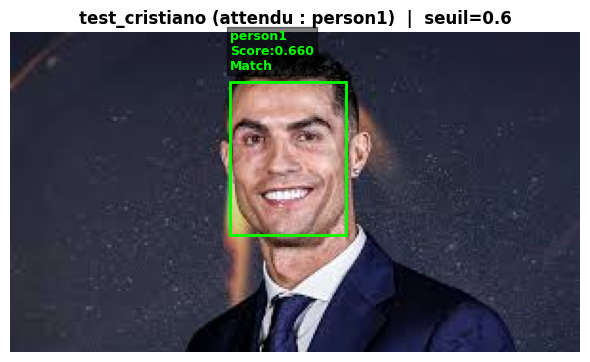


  test_messi     (attendu : person2)
    Score cosinus : 0.9412
    Identite      : person2
    Decision      : Match


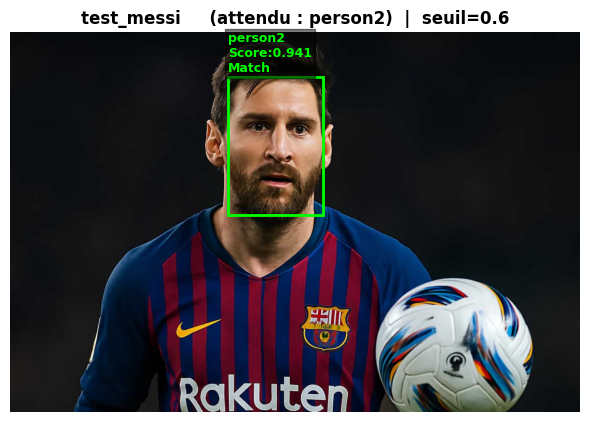


  test_inconnu   (attendu : No Match)
    Score cosinus : 0.3118
    Identite      : person1
    Decision      : No Match


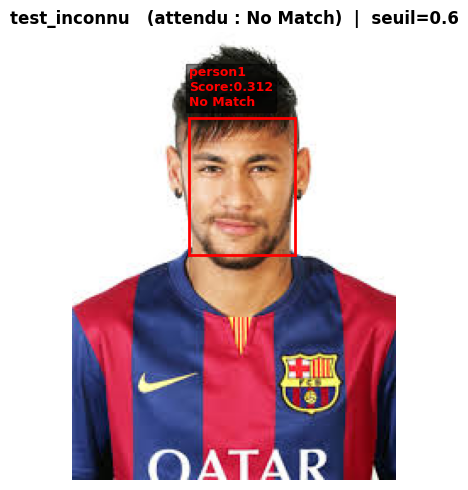


--- Comparaison directe : Cristiano vs Messi ---


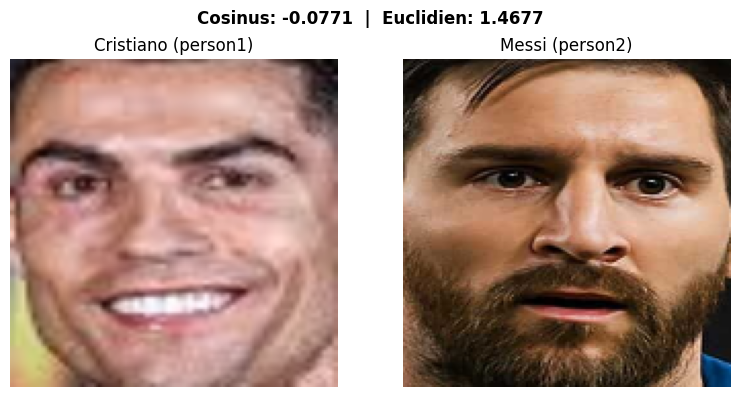


--- Comparaison directe : meme personne ---


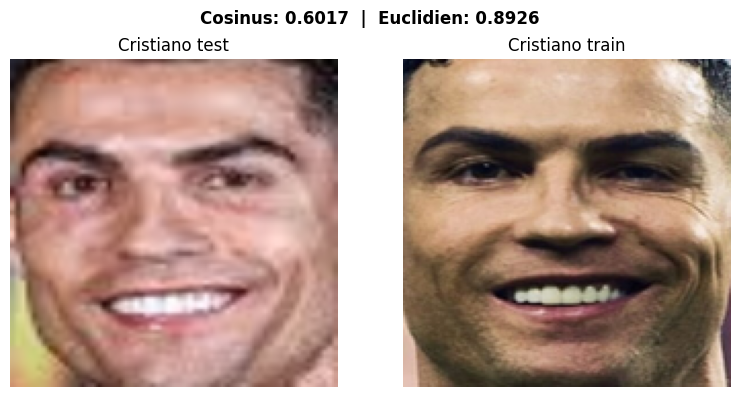


  EXPERIMENTATION A : Euclidien vs Cosinus

  Image                     Vrai        Cosinus    Pred       Dec    | Euclidien    Pred       Dec   
  -------------------------------------------------------------------------------------
  test_cristiano.jpg        person1      0.6595  person1     Match   |    0.8252  person1   No Match 
  test_messi.jpeg           person2      0.9412  person2     Match   |    0.3428  person2     Match  
  test_inconnu.jpg          unknown      0.3118  person1   No Match  |    1.1732  person1   No Match 


  EXPERIMENTATION B : Effet du seuil (cosine)

  Image                       Score cosinus  Pred
  -------------------------------------------------------
  test_cristiano.jpg                 0.6595  person1
  test_messi.jpeg                    0.9412  person2
  test_inconnu.jpg                   0.3118  person1

     Seuil  Taux_Reco%   Faux_Rejets   Fausses_Accept
  ----------------------------------------------------
      0.30        66.7           

In [9]:
def main():
    # ── Chemins ────────────────────────────────────────────────────
    DATASET_PATH = "/content/drive/MyDrive/tp5/dataset"
    TEST_DIR     = "/content/drive/MyDrive/tp5/test"

    TEST_CRISTIANO = f"{TEST_DIR}/test_cristiano.jpg"
    TEST_MESSI     = f"{TEST_DIR}/test_messi.jpeg"
    TEST_INCONNU   = f"{TEST_DIR}/test_inconnu.jpg"

    THRESHOLD_COS = 0.6    # seuil cosinus typique FaceNet
    THRESHOLD_EUC = 0.8    # seuil euclidien typique FaceNet

    print("TP05 - Reconnaissance Faciale Deep Learning (FaceNet)")
    print("=" * 55)

    # ── ETAPE 1 : Initialisation + construction de la base ─────────
    model = FaceRecognitionDL(model_name="Facenet")
    model.build_database(DATASET_PATH)

    # ── ETAPE 2 : Tests sur les 3 images separees ──────────────────
    print("\n" + "="*55)
    print("  TESTS DE RECONNAISSANCE")
    print("="*55)

    test_cases = [
        (TEST_CRISTIANO, "test_cristiano (attendu : person1)"),
        (TEST_MESSI,     "test_messi     (attendu : person2)"),
        (TEST_INCONNU,   "test_inconnu   (attendu : No Match)"),
    ]

    for img_path, description in test_cases:
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            print(f"\n  Image introuvable : {img_path}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        result = model.recognize(img_rgb, threshold=THRESHOLD_COS, metric='cosine')
        print(f"\n  {description}")
        print(f"    Score cosinus : {result['distance']:.4f}")
        print(f"    Identite      : {result['identity']}")
        print(f"    Decision      : {result['decision']}")
        display_result(img_rgb, result,
                       title=f"{description}  |  seuil={THRESHOLD_COS}")

    # ── ETAPE 3 : Comparaison visuelle de deux visages ─────────────
    print("\n--- Comparaison directe : Cristiano vs Messi ---")
    show_embeddings_comparison(
        model,
        TEST_CRISTIANO, "Cristiano (person1)",
        TEST_MESSI,     "Messi (person2)"
    )

    print("\n--- Comparaison directe : meme personne ---")
    show_embeddings_comparison(
        model,
        TEST_CRISTIANO, "Cristiano test",
        f"{DATASET_PATH}/person1/img1.jpg", "Cristiano train"
    )

    # ── ETAPE 4 : Experimentation A — Euclidien vs Cosinus ─────────
    test_images = [
        (TEST_CRISTIANO, "person1"),
        (TEST_MESSI,     "person2"),
        (TEST_INCONNU,   "unknown"),
    ]
    experiment_metrics(model, test_images)

    # ── ETAPE 5 : Experimentation B — Effet du seuil ───────────────
    experiment_threshold(model, test_images, metric='cosine')
    experiment_threshold(model, test_images, metric='euclidean')

main()